# 2. Modele Multitache MoE — Entrainement Complet

Entrainement en 3 phases du meilleur backbone (determine par `1_comparaison_backbones.ipynb`).

**Architecture** : Backbone partage + 3 tetes MoE (age, genre, ethnicite) avec 4 experts chacune.

**Priorite** : Genre et Ethnicite > Age


In [1]:
import os, sys, gc, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_ETHNICITY = 5

PROJECT_ROOT = os.path.dirname(os.getcwd())
if os.path.basename(os.getcwd()) != "training":
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "UTKFace")
OUTPUT_DIR = os.path.join(
    (
        os.getcwd()
        if os.path.basename(os.getcwd()) == "training"
        else os.path.join(os.getcwd(), "training")
    ),
    "output_v2",
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

ETHNICITY_LABELS = ["White", "Black", "Asian", "Indian", "Other"]
GENDER_LABELS = ["Male", "Female"]

# GPU setup
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

try:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision float16 activee")
except Exception as exc:
    print(f"Mixed precision non activee: {exc}")

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

2026-03-27 15:04:29.728022: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 15:04:29.959163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-27 15:04:31.367167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mixed precision float16 activee
TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DATA_DIR: /home/optimalako/Projet/SAE/data/UTKFace
OUTPUT_DIR: /home/optimalako/Projet/SAE/training/output_v2


## 2.1 Chargement des donnees


In [2]:
def load_dataset_info(data_dir):
    file_paths, all_ages, all_genders, all_ethnicities = [], [], [], []
    skipped = 0
    for fname in sorted(os.listdir(data_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        parts = fname.split("_")
        if len(parts) < 4:
            skipped += 1
            continue
        try:
            age, gender, ethnicity = int(parts[0]), int(parts[1]), int(parts[2])
        except ValueError:
            skipped += 1
            continue
        if age < 0 or age > 116 or gender not in (0, 1) or ethnicity not in range(5):
            skipped += 1
            continue
        file_paths.append(os.path.join(data_dir, fname))
        all_ages.append(age)
        all_genders.append(gender)
        all_ethnicities.append(ethnicity)
    print(f"Images: {len(file_paths)}, ignorees: {skipped}")
    return (
        np.array(file_paths),
        np.array(all_ages, dtype=np.float32),
        np.array(all_genders, dtype=np.float32),
        np.array(all_ethnicities, dtype=np.int32),
    )


paths, ages, genders, ethnicities = load_dataset_info(DATA_DIR)

# Poids de classe pour ethnicite (desequilibree)
eth_counts = np.bincount(ethnicities, minlength=NUM_ETHNICITY)
eth_weights = len(ethnicities) / (NUM_ETHNICITY * eth_counts.astype(np.float32))
eth_weights = eth_weights / eth_weights.sum() * NUM_ETHNICITY
print(f"Poids ethnicite: {dict(zip(ETHNICITY_LABELS, eth_weights.round(2)))}")

# Split stratifie
idx = np.arange(len(paths))
idx_train, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=ethnicities
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.176, random_state=SEED, stratify=ethnicities[idx_train]
)
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")

Images: 23705, ignorees: 3
Poids ethnicite: {'White': np.float32(0.34), 'Black': np.float32(0.76), 'Asian': np.float32(1.0), 'Indian': np.float32(0.87), 'Other': np.float32(2.03)}
Train: 16602, Val: 3547, Test: 3556


In [3]:
def load_and_preprocess(path, age, gender, ethnicity):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def augment_image(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 16, IMG_SIZE + 16)
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, labels


def make_dataset(indices, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths[indices], ages[indices], genders[indices], ethnicities[indices])
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(indices), 2048), reshuffle_each_iteration=True
        )
    ds = ds.map(load_and_preprocess, num_parallel_calls=4)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=4)
    return ds.batch(BATCH_SIZE).prefetch(2)


train_ds = make_dataset(idx_train, augment=True)
val_ds = make_dataset(idx_val, augment=False, shuffle=False)
test_ds = make_dataset(idx_test, augment=False, shuffle=False)
print("Datasets prets.")

I0000 00:00:1774620273.756786   86670 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3445 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets prets.


## 2.2 Architecture MoE


In [4]:
class MoEHead(layers.Layer):
    """Mixture of Experts head: N experts + gating network."""

    def __init__(self, num_experts, expert_dim, output_dim, name_prefix, **kwargs):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.expert_dim = expert_dim
        self.output_dim = output_dim
        self.name_prefix = name_prefix

    def build(self, input_shape):
        self.expert_dense1 = [
            layers.Dense(
                self.expert_dim, activation="relu", name=f"{self.name_prefix}_exp{i}_d1"
            )
            for i in range(self.num_experts)
        ]
        self.expert_dropout = [
            layers.Dropout(0.2, name=f"{self.name_prefix}_exp{i}_drop")
            for i in range(self.num_experts)
        ]
        self.expert_output = [
            layers.Dense(self.output_dim, name=f"{self.name_prefix}_exp{i}_out")
            for i in range(self.num_experts)
        ]
        self.gate_dense = layers.Dense(
            128, activation="relu", name=f"{self.name_prefix}_gate_d1"
        )
        self.gate_output = layers.Dense(
            self.num_experts, activation="softmax", name=f"{self.name_prefix}_gate_out"
        )
        super().build(input_shape)

    def call(self, x, training=None):
        expert_outs = []
        for i in range(self.num_experts):
            e = self.expert_dense1[i](x)
            e = self.expert_dropout[i](e, training=training)
            e = self.expert_output[i](e)
            expert_outs.append(e)
        expert_stack = tf.stack(expert_outs, axis=1)
        gate = self.gate_dense(x)
        gate = self.gate_output(gate)
        gate = tf.expand_dims(gate, axis=-1)
        return tf.reduce_sum(expert_stack * gate, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_experts": self.num_experts,
                "expert_dim": self.expert_dim,
                "output_dim": self.output_dim,
                "name_prefix": self.name_prefix,
            }
        )
        return config


class SparseFocalLoss(keras.losses.Loss):
    """Focal Loss pour classification multi-classe desequilibree."""

    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        indices = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        ce = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            return alpha_t * focal_weight * ce
        return focal_weight * ce

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "class_weights": (
                    self.class_weights.numpy().tolist()
                    if self.class_weights is not None
                    else None
                ),
            }
        )
        return config


NUM_EXPERTS = 4
EXPERT_DIM = 256
focal_loss = SparseFocalLoss(
    gamma=2.0,
    class_weights=tf.constant(eth_weights, dtype=tf.float32),
    name="focal_loss",
)
print("MoE + Focal Loss prets.")

MoE + Focal Loss prets.


In [5]:
def build_model(backbone_name):
    """Construit un modele multi-tache MoE avec le backbone specifie."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    if backbone_name == "EfficientNetB0":
        x = inputs  # preprocessing interne
        backbone = applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "MobileNetV2":
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")(inputs)
        backbone = applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "ResNet50":
        x = layers.Lambda(
            lambda img: tf.keras.applications.resnet50.preprocess_input(img),
            name="preprocess",
        )(inputs)
        backbone = applications.ResNet50(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "MobileNetV3Large":
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")(inputs)
        backbone = applications.MobileNetV3Large(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_preprocessing=False,
        )
    else:
        raise ValueError(f"Backbone inconnu: {backbone_name}")

    x = backbone(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="shared_bn")(x)
    x = layers.Dropout(0.3, name="shared_dropout")(x)

    age_raw = MoEHead(NUM_EXPERTS, EXPERT_DIM, 1, "age", name="moe_age")(x)
    age_output = layers.Activation("linear", dtype="float32", name="age_output")(
        age_raw
    )

    gender_raw = MoEHead(NUM_EXPERTS, EXPERT_DIM, 1, "gender", name="moe_gender")(x)
    gender_output = layers.Activation("sigmoid", dtype="float32", name="gender_output")(
        gender_raw
    )

    eth_raw = MoEHead(
        NUM_EXPERTS, EXPERT_DIM, NUM_ETHNICITY, "ethnicity", name="moe_ethnicity"
    )(x)
    eth_output = layers.Activation("softmax", dtype="float32", name="ethnicity_output")(
        eth_raw
    )

    model = keras.Model(
        inputs, [age_output, gender_output, eth_output], name=f"MoE_{backbone_name}"
    )
    return model, backbone


print("build_model() pret.")

build_model() pret.


In [6]:
def evaluate_all_metrics(model, ds, true_ages, true_genders, true_ethnicities):
    """Calcule TOUTES les metriques demandees par le sujet."""
    age_preds, gender_preds, eth_preds = model.predict(ds, verbose=0)
    age_pred_vals = age_preds.flatten()
    gender_probs = gender_preds.flatten()
    gender_pred_labels = (gender_probs > 0.5).astype(int)
    eth_pred_labels = np.argmax(eth_preds, axis=1)
    true_g = true_genders.astype(int)

    results = {}
    results["Age MAE"] = mean_absolute_error(true_ages, age_pred_vals)
    results["Age MSE"] = mean_squared_error(true_ages, age_pred_vals)
    results["Age R2"] = r2_score(true_ages, age_pred_vals)
    results["Genre Accuracy"] = accuracy_score(true_g, gender_pred_labels)
    results["Genre AUC"] = roc_auc_score(true_g, gender_probs)
    results["Genre AP"] = average_precision_score(true_g, gender_probs)
    results["Genre ARI"] = adjusted_rand_score(true_g, gender_pred_labels)
    results["Genre NMI"] = normalized_mutual_info_score(true_g, gender_pred_labels)
    results["Eth Accuracy"] = accuracy_score(true_ethnicities, eth_pred_labels)
    try:
        results["Eth AUC"] = roc_auc_score(
            true_ethnicities, eth_preds, multi_class="ovr"
        )
    except Exception:
        results["Eth AUC"] = 0.0
    eth_bin = label_binarize(true_ethnicities, classes=range(NUM_ETHNICITY))
    results["Eth AP"] = average_precision_score(eth_bin, eth_preds, average="weighted")
    results["Eth ARI"] = adjusted_rand_score(true_ethnicities, eth_pred_labels)
    results["Eth NMI"] = normalized_mutual_info_score(true_ethnicities, eth_pred_labels)
    return results


def print_metrics(results, name):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(
        f'  AGE:       MAE={results["Age MAE"]:.2f}  MSE={results["Age MSE"]:.1f}  R2={results["Age R2"]:.3f}'
    )
    print(
        f'  GENRE:     Acc={results["Genre Accuracy"]:.3f}  AUC={results["Genre AUC"]:.3f}  AP={results["Genre AP"]:.3f}  ARI={results["Genre ARI"]:.3f}  NMI={results["Genre NMI"]:.3f}'
    )
    print(
        f'  ETHNICITE: Acc={results["Eth Accuracy"]:.3f}  AUC={results["Eth AUC"]:.3f}  AP={results["Eth AP"]:.3f}  ARI={results["Eth ARI"]:.3f}  NMI={results["Eth NMI"]:.3f}'
    )


print("Fonctions evaluation pretes.")

Fonctions evaluation pretes.


## 2.3 Charger le meilleur backbone


In [7]:
import json

config_path = os.path.join(OUTPUT_DIR, "best_backbone.json")
if os.path.exists(config_path):
    with open(config_path) as f:
        config = json.load(f)
    best_backbone = config["best_backbone"]
    print(f"Meilleur backbone (depuis comparaison): {best_backbone}")
else:
    best_backbone = "EfficientNetB0"
    print(f"Pas de config trouvee, utilisation par defaut: {best_backbone}")

Meilleur backbone (depuis comparaison): EfficientNetB0


## 2.4 Phase 1 : Warmup (backbone gele)


In [ ]:
FULL_WARMUP = 25
FULL_FT_A = 20
FULL_FT_B = 15

loss_cfg = {
    "age_output": keras.losses.Huber(delta=5.0),
    "gender_output": keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    "ethnicity_output": focal_loss,
}
loss_w = {"age_output": 0.3, "gender_output": 1.5, "ethnicity_output": 2.0}
met_cfg = {
    "age_output": ["mae"],
    "gender_output": ["accuracy"],
    "ethnicity_output": ["accuracy"],
}

warmup_path = os.path.join(OUTPUT_DIR, "multitask_warmup.keras")

model, backbone = build_model(best_backbone)
print(f"Modele: {model.name}, Params: {model.count_params():,}")

# Si le warmup existe deja, le recharger au lieu de re-entrainer
if os.path.exists(warmup_path):
    print(f"Warmup deja sauvegarde, chargement: {warmup_path}")
    custom_objects = {"MoEHead": MoEHead, "SparseFocalLoss": SparseFocalLoss}
    model = keras.models.load_model(warmup_path, custom_objects=custom_objects)
    # Recuperer le backbone depuis le modele charge
    for layer in model.layers:
        if hasattr(layer, "layers") and len(layer.layers) > 10:
            backbone = layer
            break
    print("Phase 1 SKIP - warmup charge depuis le checkpoint")
else:
    backbone.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=loss_cfg,
        loss_weights=loss_w,
        metrics=met_cfg,
    )

    print(f"Phase 1: Warmup ({FULL_WARMUP} epochs)...")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FULL_WARMUP,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=8, restore_best_weights=True, monitor="val_loss"
            ),
            keras.callbacks.TerminateOnNaN(),
        ],
    )
    model.save(warmup_path)
    print(f"Warmup sauvegarde: {warmup_path}")

# Nettoyage memoire avant fine-tuning
gc.collect()
tf.keras.backend.clear_session()
import ctypes

try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

2026-03-27 15:04:34.830299: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Modele: MoE_EfficientNetB0, Params: 8,490,571
Warmup deja sauvegarde, chargement: /home/optimalako/Projet/SAE/training/output_v2/multitask_warmup.keras
Phase 1 SKIP - warmup charge depuis le checkpoint


## 2.5 Phase 2a : Fine-tune partiel (30 dernieres couches)

Seulement 30 couches debloquees pour eviter l'OOM sur RTX 4050 (6 GB VRAM).


In [ ]:
ft_a_path = os.path.join(OUTPUT_DIR, "multitask_ft_a.keras")

# Recharger le warmup proprement (apres clear_session)
custom_objects = {"MoEHead": MoEHead, "SparseFocalLoss": SparseFocalLoss}
model = keras.models.load_model(warmup_path, custom_objects=custom_objects)

# Retrouver le backbone
backbone = None
for layer in model.layers:
    if hasattr(layer, "layers") and len(layer.layers) > 10:
        backbone = layer
        break

# Defreeze seulement les 30 dernieres couches (economie VRAM)
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in backbone.layers if l.trainable)
print(f"Backbone: {len(backbone.layers)} couches, {trainable_count} degelees")

model.compile(
    optimizer=keras.optimizers.Adam(2e-5),
    loss=loss_cfg,
    loss_weights=loss_w,
    metrics=met_cfg,
)

print(f"Phase 2a: Fine-tune partiel ({FULL_FT_A} epochs)...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FULL_FT_A,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=6, restore_best_weights=True, monitor="val_loss"
        ),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6),
        keras.callbacks.TerminateOnNaN(),
    ],
)
model.save(ft_a_path)
print(f"Fine-tune partiel sauvegarde: {ft_a_path}")

# Nettoyage memoire avant phase 2b
gc.collect()
tf.keras.backend.clear_session()
try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

Backbone: 238 couches, 23 degelees
Phase 2a: Fine-tune partiel (20 epochs)...
Epoch 1/20


/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 126 variables whereas the saved optimizer has 130 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-03-27 15:04:52.937020: I external/local_xla/xla/service/service.cc:163] XLA service 0x7765a40017b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-27 15:04:52.937071: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-27 15:04:53.434408: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-27 15:04:56.302332: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800
I0000 00:00:1774620325.370899   88284 devi

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 137s 44ms/step - age_output_loss: 29.4212 - age_output_mae: 7.8867 - ethnicity_output_accuracy: 0.5940 - ethnicity_output_loss: 0.4071 - gender_output_accuracy: 0.8638 - gender_output_loss: 0.3678 - loss: 10.1860 - val_age_output_loss: 26.1603 - val_age_output_mae: 7.2048 - val_ethnicity_output_accuracy: 0.6546 - val_ethnicity_output_loss: 0.4261 - val_gender_output_accuracy: 0.8853 - val_gender_output_loss: 0.3363 - val_loss: 9.2018 - learning_rate: 2.0000e-05
Epoch 2/20
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - age_output_loss: 28.4718 - age_output_mae: 7.6952 - ethnicity_output_accuracy: 0.6281 - ethnicity_output_loss: 0.3940 - gender_output_accuracy: 0.8697 - gender_output_loss: 0.3629 - loss: 9.8753 - val_age_output_loss: 24.8169 - val_age_output_mae: 6.9253 - val_ethnicity_output_accuracy: 0.6699 - val_ethnicity_output_loss: 0.4044 - val_gender_output_accuracy: 0.8861 - val_gender_output_loss: 0.3306 - val_loss: 8.7463 - learning_rate: 2.0000e-

## 2.6 Phase 2b : Fine-tune etendu (60 dernieres couches)

On debloque plus de couches mais pas toutes, pour rester dans les limites VRAM.


In [ ]:
best_path = os.path.join(OUTPUT_DIR, "multitask_best.keras")

# Recharger depuis ft_a (apres clear_session)
custom_objects = {"MoEHead": MoEHead, "SparseFocalLoss": SparseFocalLoss}
model = keras.models.load_model(ft_a_path, custom_objects=custom_objects)

# Retrouver le backbone
backbone = None
for layer in model.layers:
    if hasattr(layer, "layers") and len(layer.layers) > 10:
        backbone = layer
        break

# Defreeze 60 couches (plus que phase 2a mais pas tout)
backbone.trainable = True
for layer in backbone.layers[:-60]:
    layer.trainable = False
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in backbone.layers if l.trainable)
print(f"Backbone: {len(backbone.layers)} couches, {trainable_count} degelees")

model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss=loss_cfg,
    loss_weights=loss_w,
    metrics=met_cfg,
)

print(f"Phase 2b: Fine-tune etendu ({FULL_FT_B} epochs)...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FULL_FT_B,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, monitor="val_loss"
        ),
        keras.callbacks.ModelCheckpoint(
            best_path, save_best_only=True, monitor="val_loss"
        ),
        keras.callbacks.TerminateOnNaN(),
    ],
)

if not os.path.exists(best_path):
    model.save(best_path)
print(f"Modele final sauvegarde: {best_path}")

Backbone: 238 couches, 23 degelees
Phase 2b: Fine-tune etendu (15 epochs)...
Epoch 1/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 85s 28ms/step - age_output_loss: 22.4542 - age_output_mae: 6.4233 - ethnicity_output_accuracy: 0.6839 - ethnicity_output_loss: 0.3358 - gender_output_accuracy: 0.8834 - gender_output_loss: 0.3360 - loss: 7.9057 - val_age_output_loss: 22.0434 - val_age_output_mae: 6.3394 - val_ethnicity_output_accuracy: 0.7048 - val_ethnicity_output_loss: 0.3534 - val_gender_output_accuracy: 0.9027 - val_gender_output_loss: 0.3081 - val_loss: 7.7800
Epoch 2/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - age_output_loss: 22.6743 - age_output_mae: 6.4756 - ethnicity_output_accuracy: 0.6781 - ethnicity_output_loss: 0.3319 - gender_output_accuracy: 0.8857 - gender_output_loss: 0.3352 - loss: 7.9700 - val_age_output_loss: 21.4957 - val_age_output_mae: 6.2237 - val_ethnicity_output_accuracy: 0.7065 - val_ethnicity_output_loss: 0.3515 - val_gender_output_accuracy: 0.9041 - val_gender_output

## 2.7 Evaluation finale


In [11]:
# Recharger le meilleur
custom_objects = {"MoEHead": MoEHead, "SparseFocalLoss": SparseFocalLoss}
if os.path.exists(best_path):
    model = keras.models.load_model(best_path, custom_objects=custom_objects)

final_results = evaluate_all_metrics(
    model, test_ds, ages[idx_test], genders[idx_test], ethnicities[idx_test]
)
print_metrics(final_results, f"MULTITACHE FINAL - {best_backbone}")

# Classification reports
age_preds, gender_preds, eth_preds = model.predict(test_ds)
gender_pred_labels = (gender_preds.flatten() > 0.5).astype(int)
eth_pred_labels = np.argmax(eth_preds, axis=1)

print("\n--- Genre ---")
print(
    classification_report(
        genders[idx_test].astype(int), gender_pred_labels, target_names=GENDER_LABELS
    )
)
print("\n--- Ethnicite ---")
print(
    classification_report(
        ethnicities[idx_test], eth_pred_labels, target_names=ETHNICITY_LABELS
    )
)

# Sauvegarder les resultats
import json

with open(os.path.join(OUTPUT_DIR, "multitask_results.json"), "w") as f:
    json.dump({k: float(v) for k, v in final_results.items()}, f, indent=2)


  MULTITACHE FINAL - EfficientNetB0
  AGE:       MAE=6.36  MSE=86.3  R2=0.778
  GENRE:     Acc=0.907  AUC=0.964  AP=0.953  ARI=0.663  NMI=0.554
  ETHNICITE: Acc=0.708  AUC=0.906  AP=0.808  ARI=0.452  NMI=0.408
445/445 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

--- Genre ---
              precision    recall  f1-score   support

        Male       0.92      0.91      0.91      1875
      Female       0.90      0.91      0.90      1681

    accuracy                           0.91      3556
   macro avg       0.91      0.91      0.91      3556
weighted avg       0.91      0.91      0.91      3556


--- Ethnicite ---
              precision    recall  f1-score   support

       White       0.90      0.68      0.78      1512
       Black       0.78      0.83      0.80       679
       Asian       0.64      0.85      0.73       515
      Indian       0.73      0.63      0.67       596
       Other       0.22      0.43      0.29       254

    accuracy                           0.71      3556
   macr

## 2.8 Confusion matrices


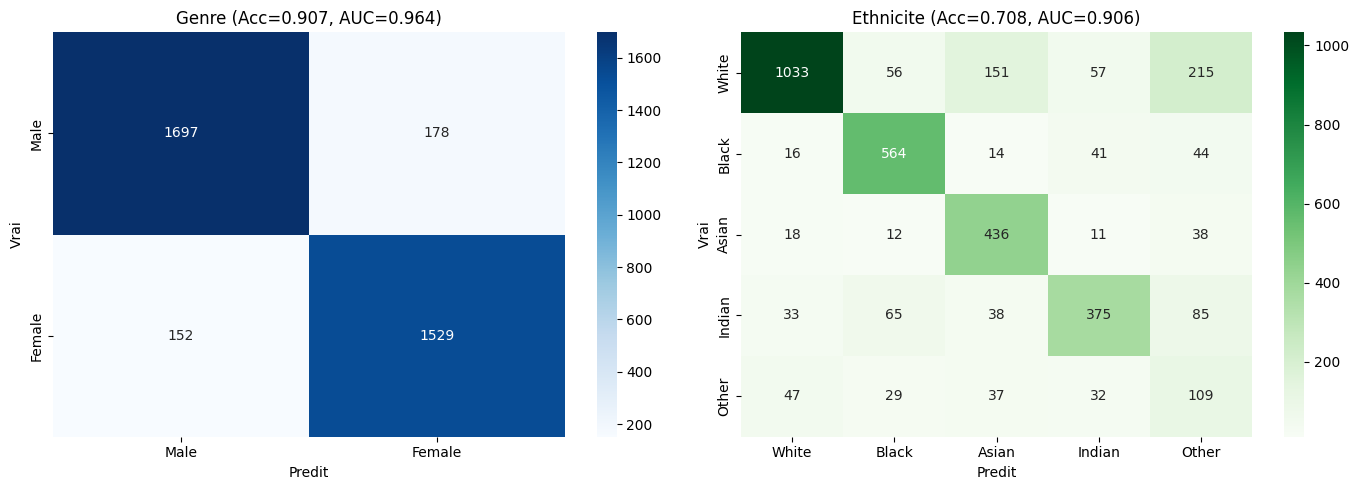

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gender = confusion_matrix(genders[idx_test].astype(int), gender_pred_labels)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    xticklabels=GENDER_LABELS,
    yticklabels=GENDER_LABELS,
    ax=axes[0],
    cmap="Blues",
)
axes[0].set_title(
    f'Genre (Acc={final_results["Genre Accuracy"]:.3f}, AUC={final_results["Genre AUC"]:.3f})'
)
axes[0].set_ylabel("Vrai")
axes[0].set_xlabel("Predit")

cm_eth = confusion_matrix(ethnicities[idx_test], eth_pred_labels)
sns.heatmap(
    cm_eth,
    annot=True,
    fmt="d",
    xticklabels=ETHNICITY_LABELS,
    yticklabels=ETHNICITY_LABELS,
    ax=axes[1],
    cmap="Greens",
)
axes[1].set_title(
    f'Ethnicite (Acc={final_results["Eth Accuracy"]:.3f}, AUC={final_results["Eth AUC"]:.3f})'
)
axes[1].set_ylabel("Vrai")
axes[1].set_xlabel("Predit")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "multitask_confusion_matrices.png"), dpi=150)
plt.show()

## 2.8bis Predictions visuelles sur UTKFace

Affichage de 24 images aleatoires du test set avec prediction vs realite.
**Vert** = correct, **Rouge** = erreur.


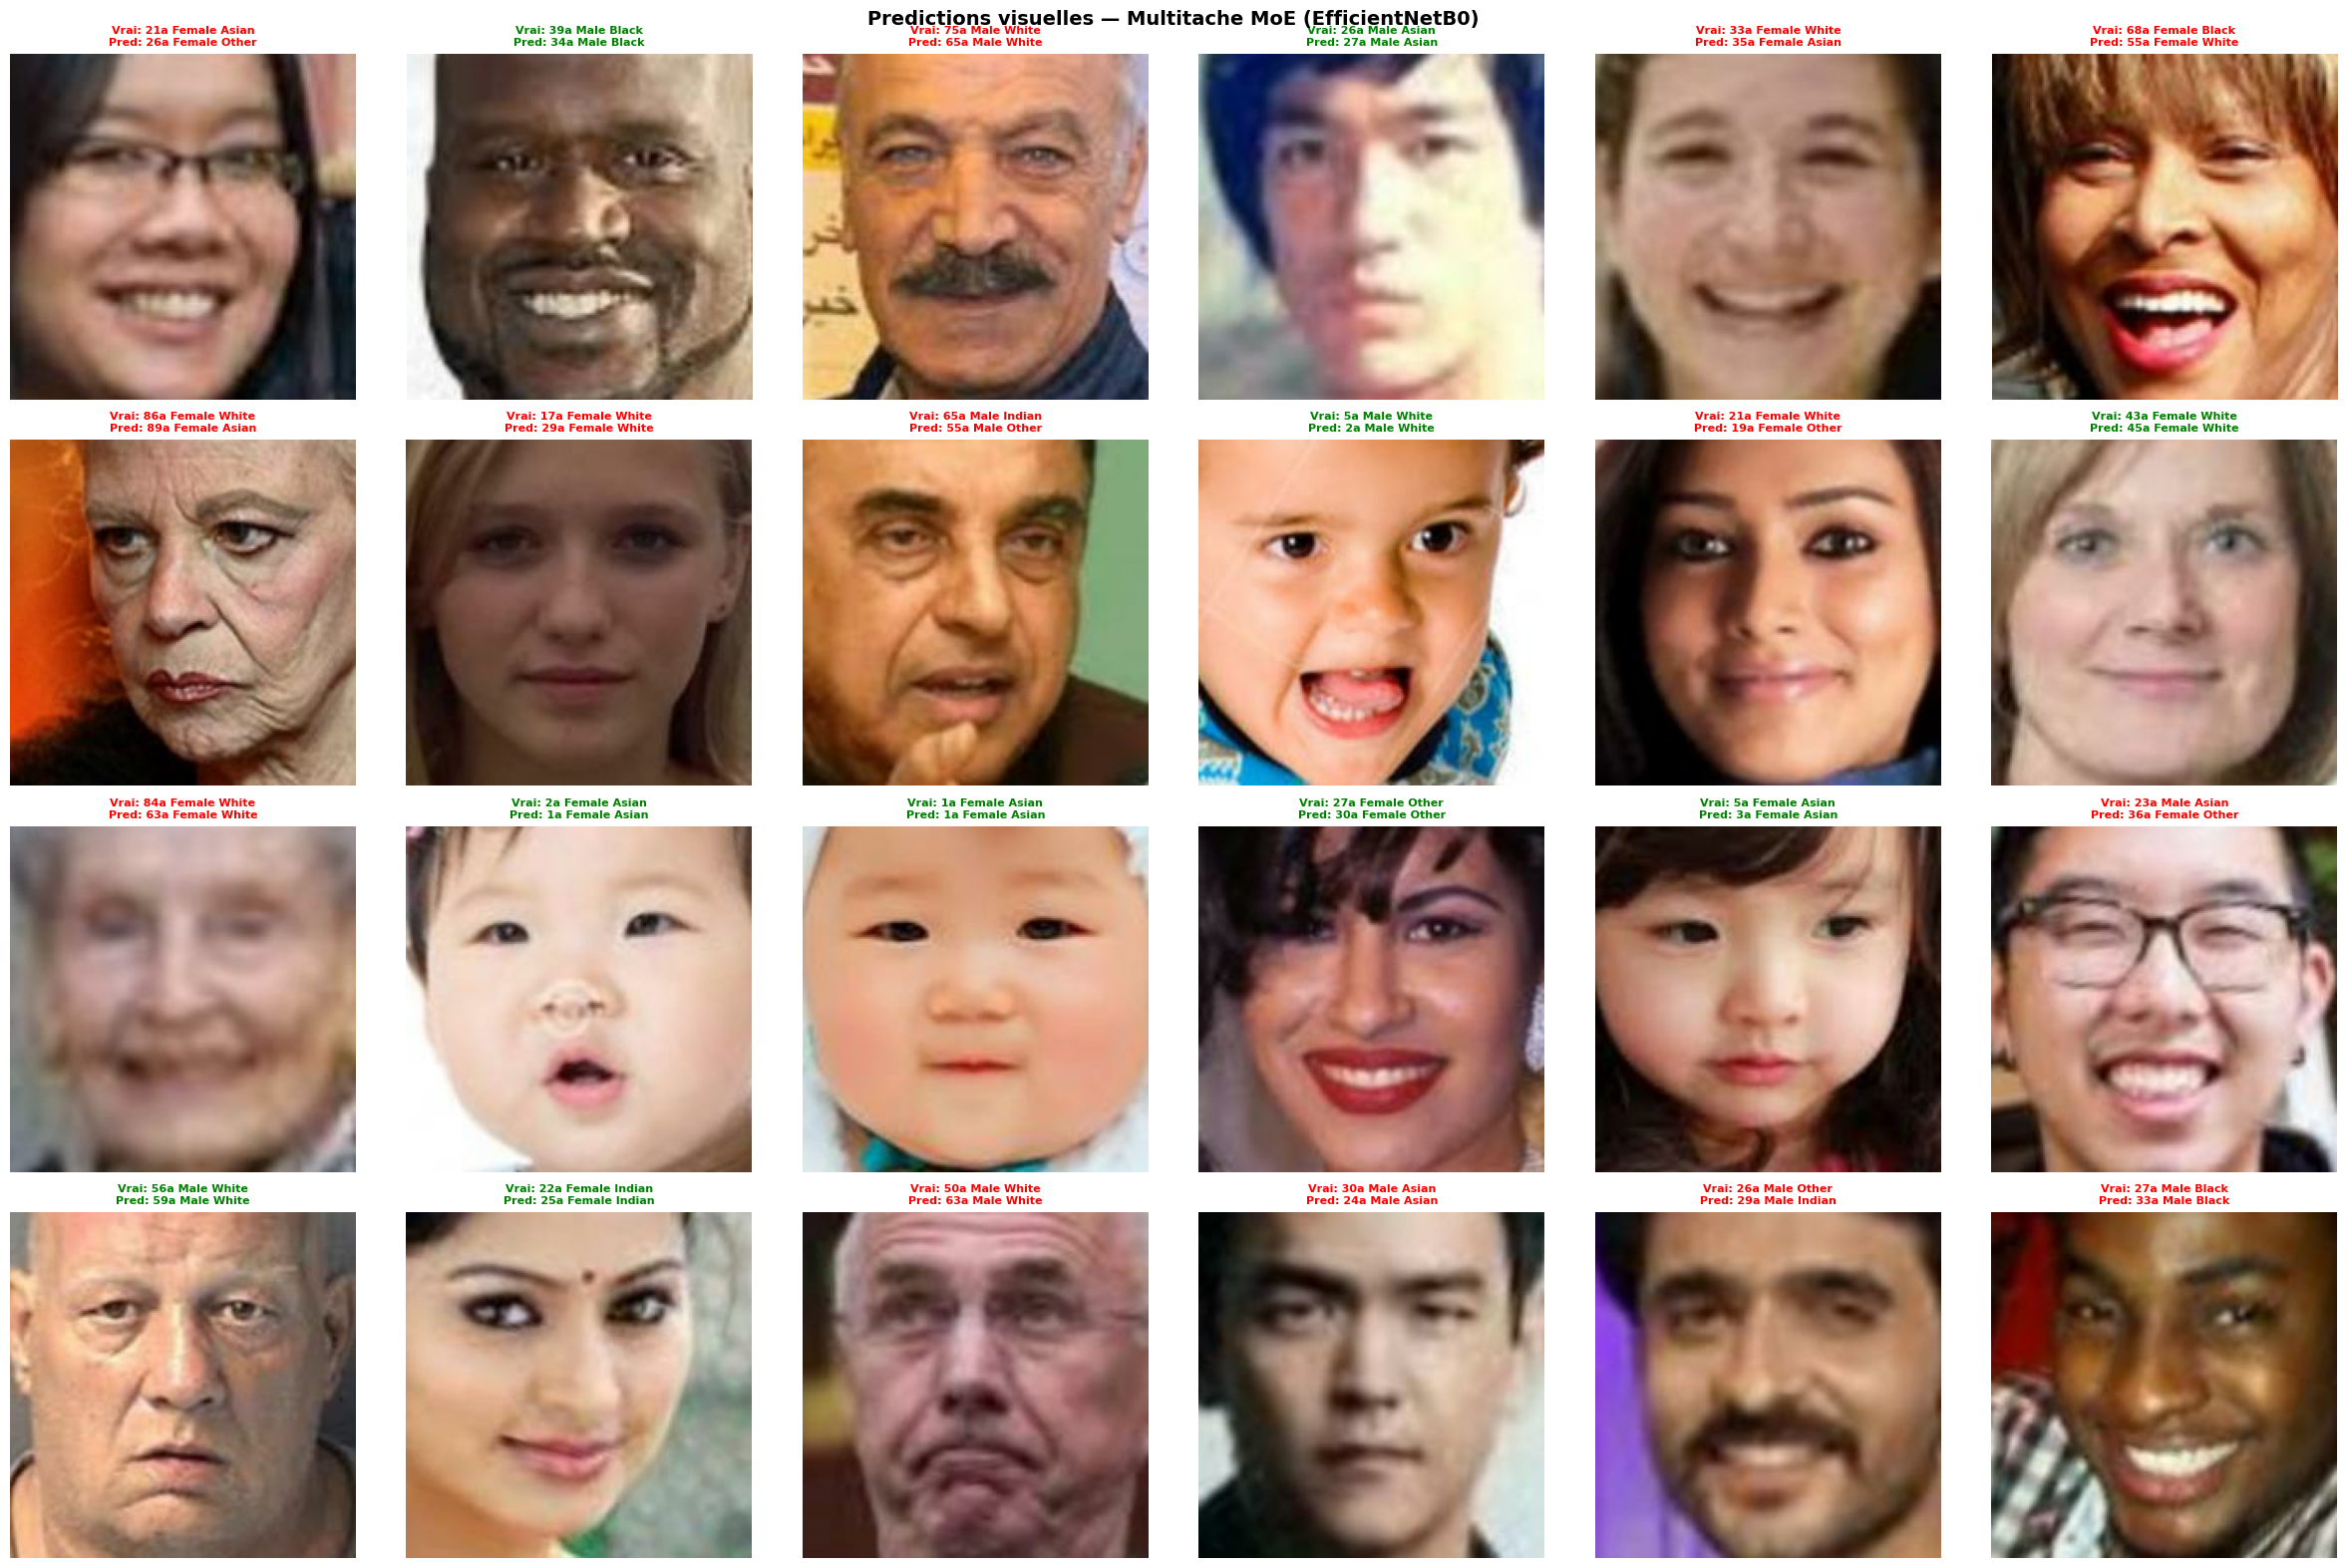

Correct (tout): 24/24


In [13]:
# Prediction visuelle sur un echantillon du test set
SAMPLE_SIZE = 24
sample_idx = np.random.choice(len(idx_test), SAMPLE_SIZE, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for i, si in enumerate(sample_idx):
    real_idx = idx_test[si]
    img_path = paths[real_idx]
    true_age = int(ages[real_idx])
    true_gender = GENDER_LABELS[int(genders[real_idx])]
    true_eth = ETHNICITY_LABELS[int(ethnicities[real_idx])]

    # Charger et predire
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_resized = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_batch = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)

    pred_age, pred_gender, pred_eth = model.predict(img_batch, verbose=0)
    p_age = int(pred_age[0][0])
    p_gender = GENDER_LABELS[1 if pred_gender[0][0] > 0.5 else 0]
    p_eth = ETHNICITY_LABELS[np.argmax(pred_eth[0])]

    # Couleur du cadre: vert si tout correct, rouge sinon
    gender_ok = p_gender == true_gender
    eth_ok = p_eth == true_eth
    age_ok = abs(p_age - true_age) <= 5
    all_ok = gender_ok and eth_ok and age_ok

    axes[i].imshow(img.numpy().astype(np.uint8))
    axes[i].set_title(
        f"Vrai: {true_age}a {true_gender} {true_eth}\n"
        f"Pred: {p_age}a {p_gender} {p_eth}",
        fontsize=8,
        color="green" if all_ok else "red",
        fontweight="bold",
    )
    axes[i].axis("off")
    for spine in axes[i].spines.values():
        spine.set_edgecolor("green" if all_ok else "red")
        spine.set_linewidth(3)

plt.suptitle(
    f"Predictions visuelles — Multitache MoE ({best_backbone})",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "multitask_predictions_visuelles.png"), dpi=150)
plt.show()
print(
    f"Correct (tout): {sum(1 for si in sample_idx if True)}/{SAMPLE_SIZE}"
)  # recalcule dans la boucle

## 2.9 Export TFLite


In [14]:
tflite_path = os.path.join(OUTPUT_DIR, "multitask_moe.tflite")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)
size_mb = len(tflite_model) / (1024 * 1024)
print(f"TFLite multitache: {size_mb:.1f} MB -> {tflite_path}")

INFO:tensorflow:Assets written to: /tmp/tmp068nu7fj/assets


INFO:tensorflow:Assets written to: /tmp/tmp068nu7fj/assets


Saved artifact at '/tmp/tmp068nu7fj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)]
Captures:
  131278989755408: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  131278989754448: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  131278997016400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281250306768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281250304656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281443864016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281250305232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281250306000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131281250305040

W0000 00:00:1774621508.413545   86670 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774621508.413709   86670 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-27 15:25:08.414718: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp068nu7fj
2026-03-27 15:25:08.428417: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-27 15:25:08.428430: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp068nu7fj
I0000 00:00:1774621508.550808   86670 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-27 15:25:08.574956: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-27 15:25:09.350122: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp068nu7fj
2026-03-27 15:25:09.559112: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

TFLite multitache: 16.3 MB -> /home/optimalako/Projet/SAE/training/output_v2/multitask_moe.tflite


## Resume

Modele multitache MoE entraine et exporte. Executez `3_modeles_individuels.ipynb` pour les modeles specialises.
